In [1]:
#!/usr/bin/python3.10

Prerequisites: pandas, xlrd, matplotlib, rpy2

# HSMC modelling

## Configuration
### It is assumed that this notebook is run from StructureAnalysis/sequence_analysis/tutorials

**Import OpenAlea packages**

In [2]:
from openalea.stat_tool import _stat_tool
from openalea.sequence_analysis import _sequence_analysis
from openalea.sequence_analysis.hidden_semi_markov import HiddenSemiMarkov
from openalea.sequence_analysis.simulate import Simulate
from openalea.sequence_analysis.data_transform import Thresholding

from openalea.stat_tool.data_transform import *
from openalea.stat_tool.cluster import Cluster
from openalea.stat_tool.cluster import Transcode, Cluster

import openalea.stat_tool.plot #import DISABLE_PLOT
from openalea.stat_tool.plot import DISABLE_PLOT
DISABLE_PLOT = False

import os

from openalea.stat_tool.output import plot, Plot

plot.DISABLE_PLOT = DISABLE_PLOT

from openalea.stat_tool.plot import get_plotter, mplotlib 

Running cmake --build & --install in /home/jdurand/devlp/Git/openalea/stat_tool/build
Running cmake --build & --install in /home/jdurand/devlp/Git/openalea/sequence_analysis/build


##### Check pandas version

In [3]:
# print pd.__version__

In [4]:
import xlrd
xlrd.__version__

'2.0.2'

For correct figure rendering

In [5]:
%matplotlib inline

##### Enabling R extensions

In [6]:
%load_ext rpy2.ipython

#####  Place variables in markdown outputs

In [7]:
from IPython.display import Markdown
from IPython.core.magic import register_cell_magic


@register_cell_magic
def markdown(line, cell):
    return Markdown(cell.format(**globals()))

## Loading and preparing data

In [8]:
import sys, os

In [9]:
sys.path

['/home/jdurand/usr/local/openalea',
 '/home/jdurand/miniforge3/envs/statdev/lib/python313.zip',
 '/home/jdurand/miniforge3/envs/statdev/lib/python3.13',
 '/home/jdurand/miniforge3/envs/statdev/lib/python3.13/lib-dynload',
 '',
 '/home/jdurand/miniforge3/envs/statdev/lib/python3.13/site-packages',
 '/home/jdurand/devlp/Git/openalea/sequence_analysis/src/openalea',
 '/home/jdurand/devlp/Git/openalea/stat_tool/src/openalea']

In [10]:
sys.path.append(".." + os.sep + "tutorials")

In [11]:
from pathlib import Path
from openalea.sequence_analysis import __path__ as seq_path
data_path = Path(seq_path[0])
data_path = str(Path.joinpath(data_path.parent.parent.parent.absolute(), "share","data"))


# Estimate HSMC with nonparametric emission distributions

nonparametric meant as categorical, saturated model

**Read an existing HSMC model**

In [12]:
from openalea.sequence_analysis import get_shared_data

model_file = "test_hidden_semi_markov.dat"

hsm = HiddenSemiMarkov(get_shared_data(model_file))

In [13]:
from openalea.sequence_analysis import Estimate
from openalea.sequence_analysis import seq_map    

Intensity is the a priori probability of states as a function of index

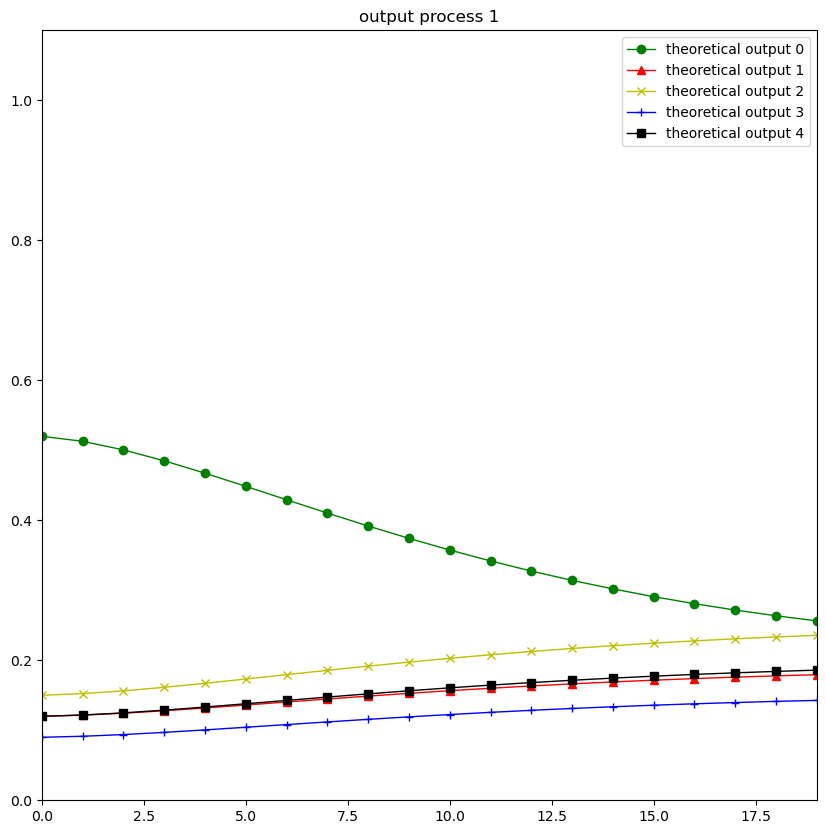

In [14]:
hsm.plot("Intensity", 1)

Emission probabilities

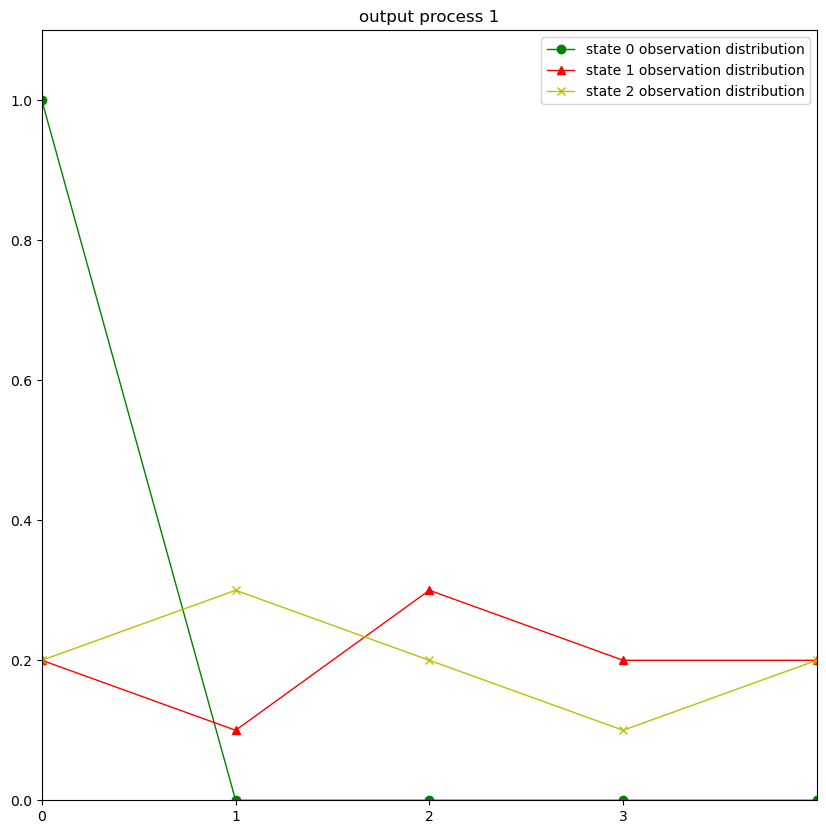

In [15]:
hsm.plot("Observation", 1)

Distributions of number of successive occurrences of values ("runs") and number of occurrences (not necessarily successive)

In [16]:
# Note that hsm.plot("Counting", 1)  replaces hsm.plot("NbRun", 1) and hsm.plot("NbOccurrence", 1)

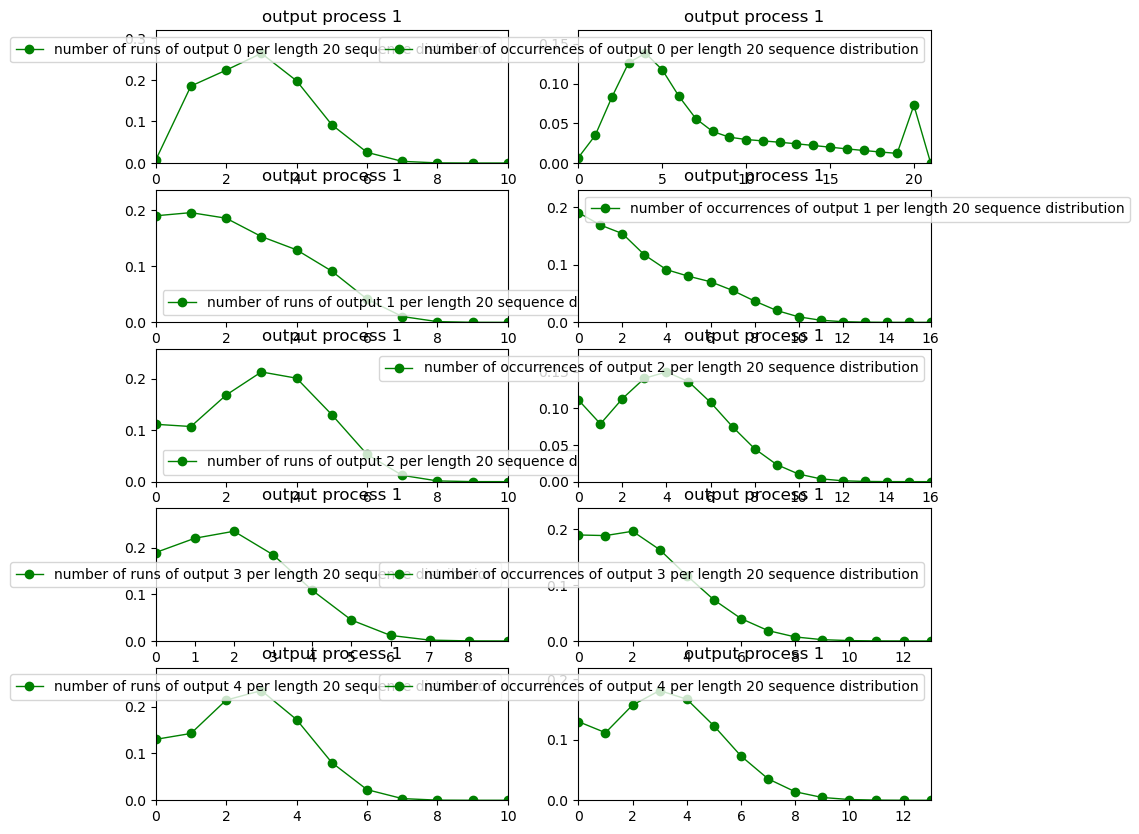

In [17]:
hsm.plot("Counting", 1)

Distributions of the number of time steps required to observe a value again once you just stopped observing it

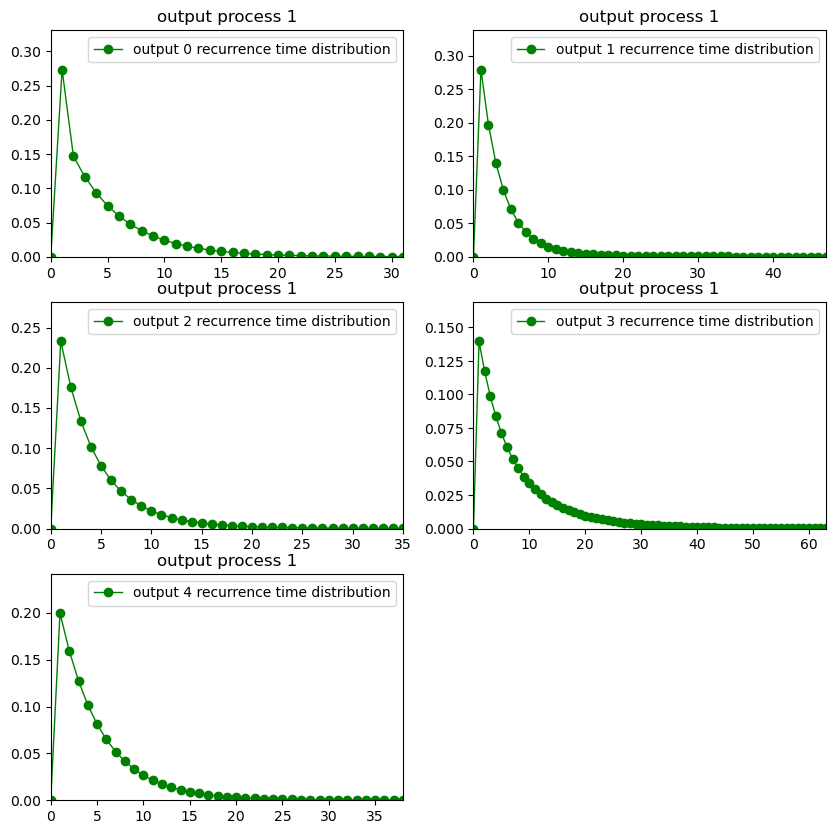

In [18]:
hsm.plot("Recurrence", 1)


Distributions of the number of time steps required to observe a value for the first time

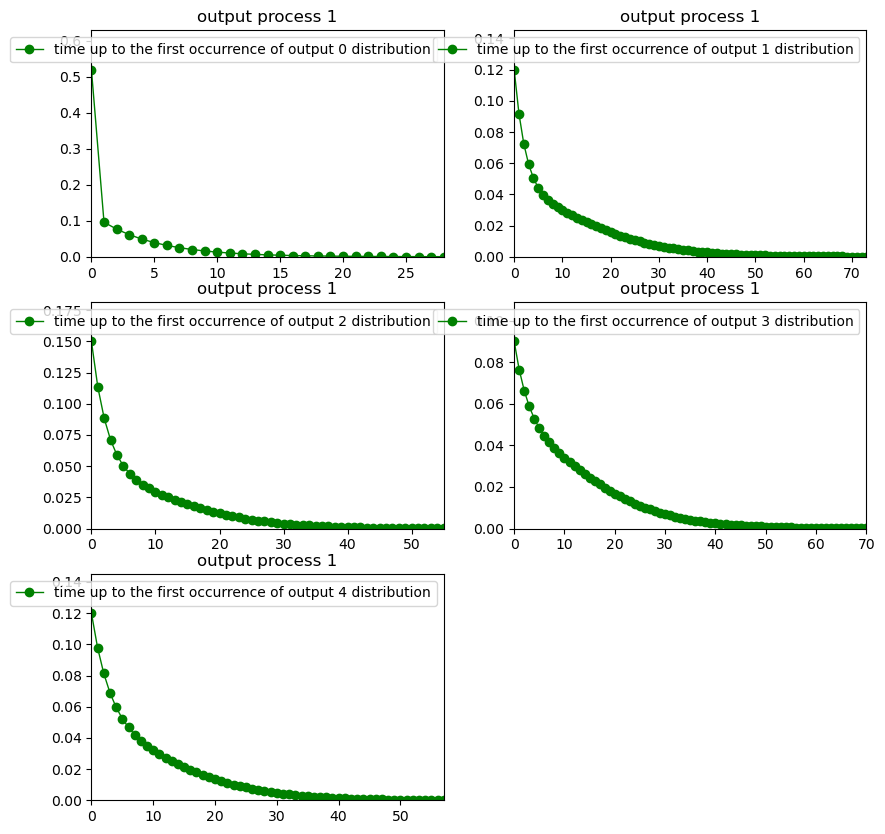

In [19]:
hsm.plot("FirstOccurrence", 1)

Distributions of the maximal number of successive occurrences of a same value

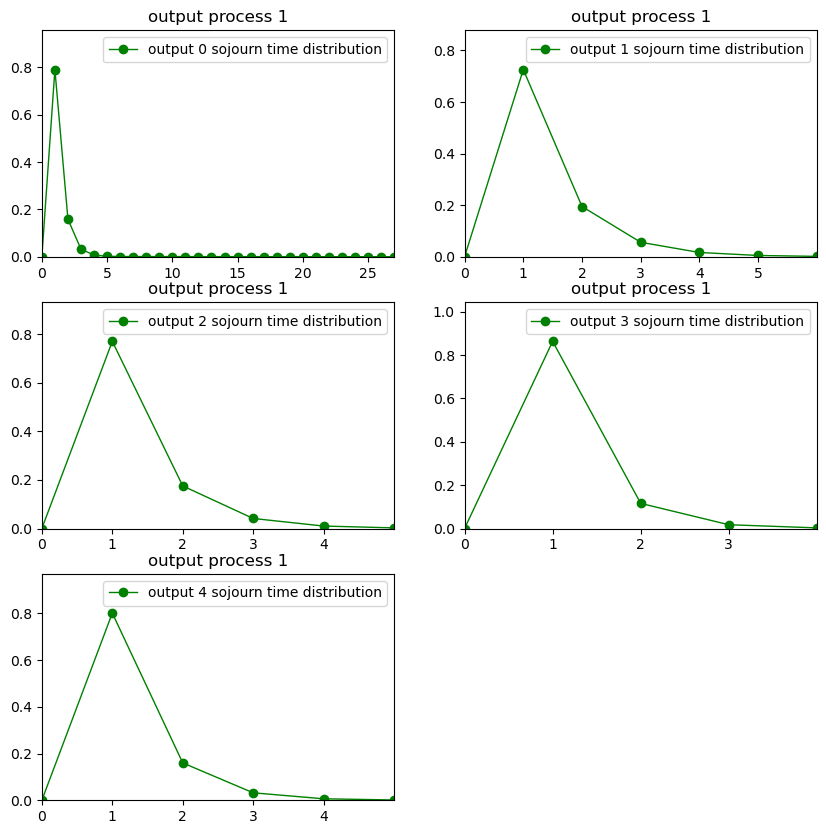

In [20]:
hsm.plot("Sojourn", 1)

In [21]:
# Would plot all above graph into a same figure, I do not recommend this.
# hsm.plot()

**Simulate sequences**

In [22]:
from openalea.sequence_analysis import Simulate

In [23]:
from openalea.stat_tool.distribution import set_seed
set_seed(0)

Simulate *nb_seq* sequences with length *seq_length*

In [24]:
nb_seq = 30
seq_length = 200
seq = hsm.simulation_nb_sequences(nb_seq, seq_length, True)
assert(len(seq) == nb_seq)
assert(len(seq[0]) == seq_length)
# NB: hsm has 1 output process but simulation includes the hidden state
assert(len(seq[0][1]) == 3)

In [25]:
seq = hsm.simulation_nb_sequences(nb_seq, seq_length, True)

In [26]:
# Print first simulated sequence.
# The first variable is the simulated state
print(seq[0])

[[0, 0, 3], [0, 0, 20], [0, 0, 2], [0, 0, 0], [0, 0, 1], [0, 0, 11], [1, 3, 4], [1, 1, 2], [1, 2, 1], [1, 3, 3], [1, 4, 3], [1, 2, 3], [1, 4, 1], [1, 3, 5], [1, 2, 5], [1, 1, 1], [1, 1, 2], [1, 4, 5], [1, 4, 2], [1, 0, 4], [1, 3, 1], [1, 2, 2], [1, 2, 2], [1, 2, 3], [1, 4, 2], [1, 0, 3], [1, 2, 4], [1, 4, 1], [1, 2, 1], [1, 4, 2], [1, 4, 2], [1, 4, 4], [1, 4, 2], [1, 2, 0], [1, 3, 0], [1, 2, 2], [1, 0, 4], [1, 4, 3], [1, 4, 2], [1, 1, 1], [1, 3, 3], [1, 0, 4], [1, 2, 3], [1, 1, 3], [1, 0, 2], [1, 4, 0], [1, 2, 1], [1, 3, 3], [1, 2, 2], [1, 2, 4], [1, 1, 3], [1, 4, 2], [1, 3, 3], [1, 2, 1], [1, 2, 1], [1, 2, 3], [1, 0, 2], [1, 1, 1], [1, 2, 1], [1, 2, 1], [1, 4, 2], [1, 4, 1], [1, 3, 4], [1, 2, 3], [1, 4, 3], [1, 2, 2], [1, 2, 2], [1, 2, 2], [1, 0, 3], [1, 2, 2], [1, 1, 3], [1, 2, 3], [1, 3, 3], [1, 4, 4], [1, 2, 1], [1, 2, 1], [1, 2, 1], [1, 2, 2], [1, 3, 2], [1, 4, 1], [1, 0, 2], [1, 1, 2], [1, 4, 4], [1, 2, 3], [1, 2, 2], [1, 0, 1], [1, 3, 4], [1, 3, 4], [1, 2, 2], [1, 0, 0], [1, 4, 

Discard variable 1 (state)

In [27]:
obs = seq.select_variable([1], keep=False)

## Plotting marginal relative frequencies of data as a function of index

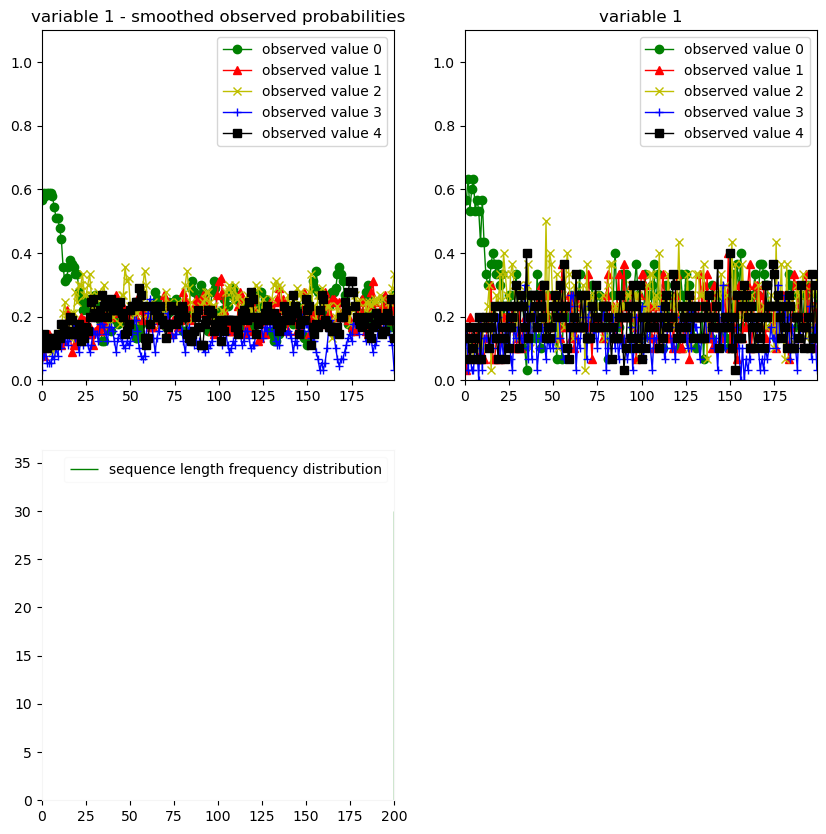

In [28]:
# Variable 1
obs.plot("Intensity", 0)

## HSCM re-estimation

### Reestimate from default initialisation

### TODO: check SOJOURN 0

In [29]:
from openalea.sequence_analysis import Estimate
nb_states = hsm.get_nb_state()

hsmc_est = Estimate(obs, "HIDDEN_SEMI-MARKOV", "Ordinary", nb_states, "Irreducible", Nbiteration=300)   
print(hsmc_est.display())

0
iteration 1   log-likelihood for the observed sequences: -30721.6
HIDDEN_SEMI-MARKOV_CHAIN

3 STATES

INITIAL_PROBABILITIES
0.0985587  0.331737   0.569704   

TRANSITION_PROBABILITIES
0          0.0293854  0.970615   
0.118267   0          0.881733   
0.231242   0.768758   0          

recurrent class: states 0 1 2

time up to the first occurrence of state 0 distribution
mean: 372.032   median: 853   mode: 0
variance: 98155.9   standard deviation: 313.298   lower quartile: 291   upper quartile: -1

time up to the first occurrence of state 0 frequency distribution - sample size: 1
mean: 149   median: 149   mode: 149
variance: 0   standard deviation: 0

time up to the first occurrence of state 1 distribution

time up to the first occurrence of state 1 frequency distribution - sample size: 24
mean: 55.1667   median: 8.5   mode: 0
variance: 5021.54   standard deviation: 70.8628   lower quartile: 0   upper quartile: 141

time up to the first occurrence of state 2 distribution

time up to 

## Plotting marginal relative frequencies of data and predicted probabilities as a function of index

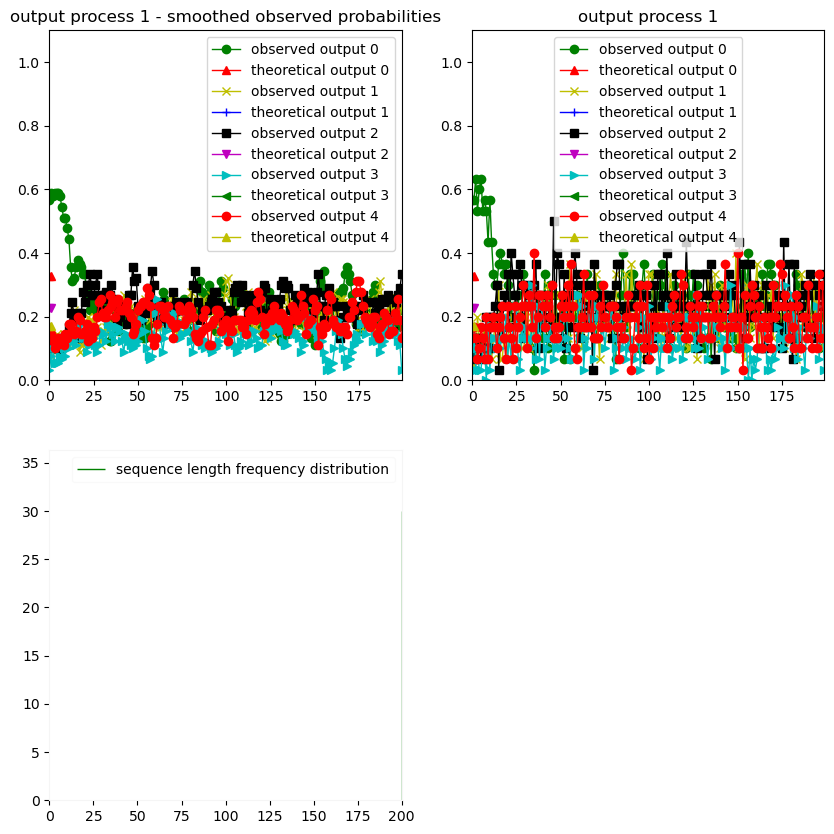

In [30]:
hsmc_est.plot("Intensity", 1)

## Observation (i.e., emission) distributions

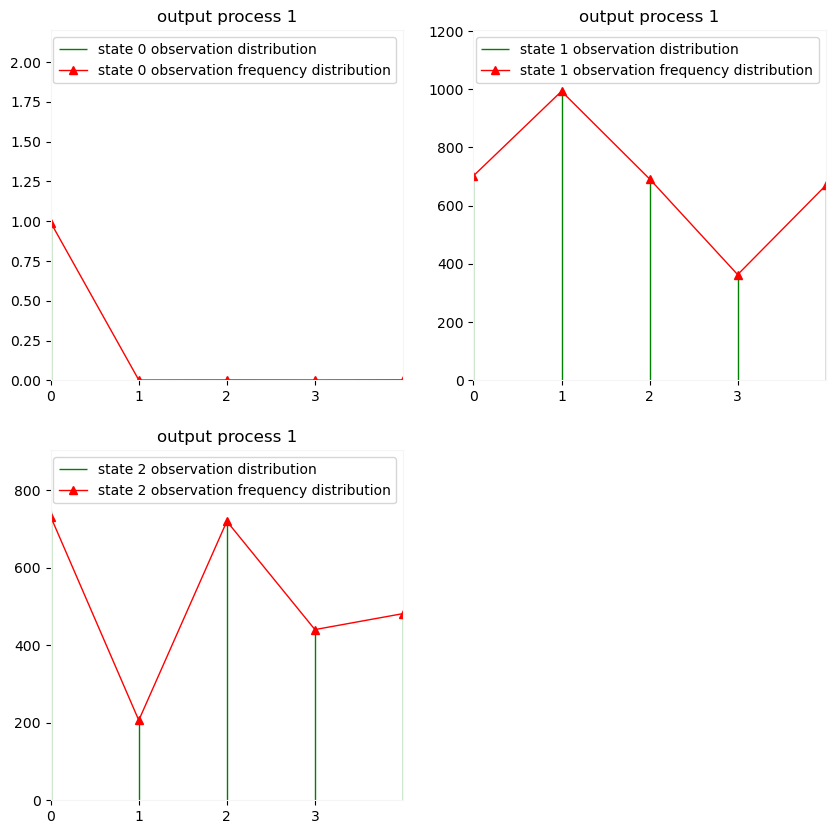

In [31]:
hsmc_est.plot("Observation", 1)


This continues as before: empirical and predicted statistics

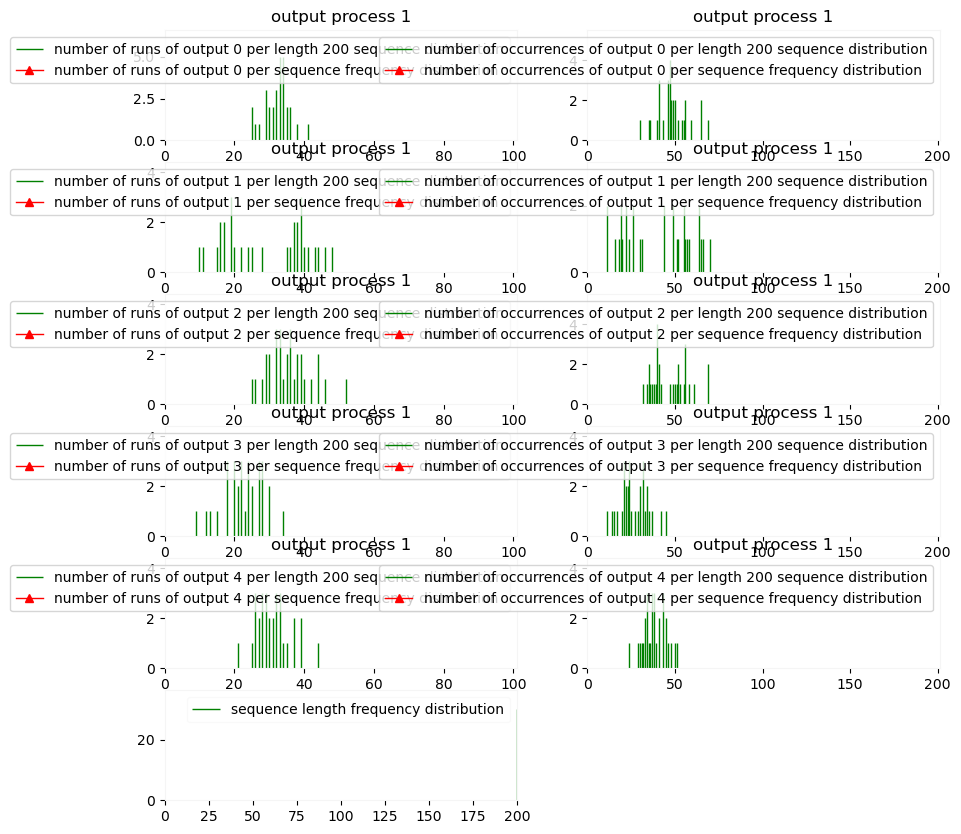

In [32]:
hsmc_est.plot("Counting", 1)


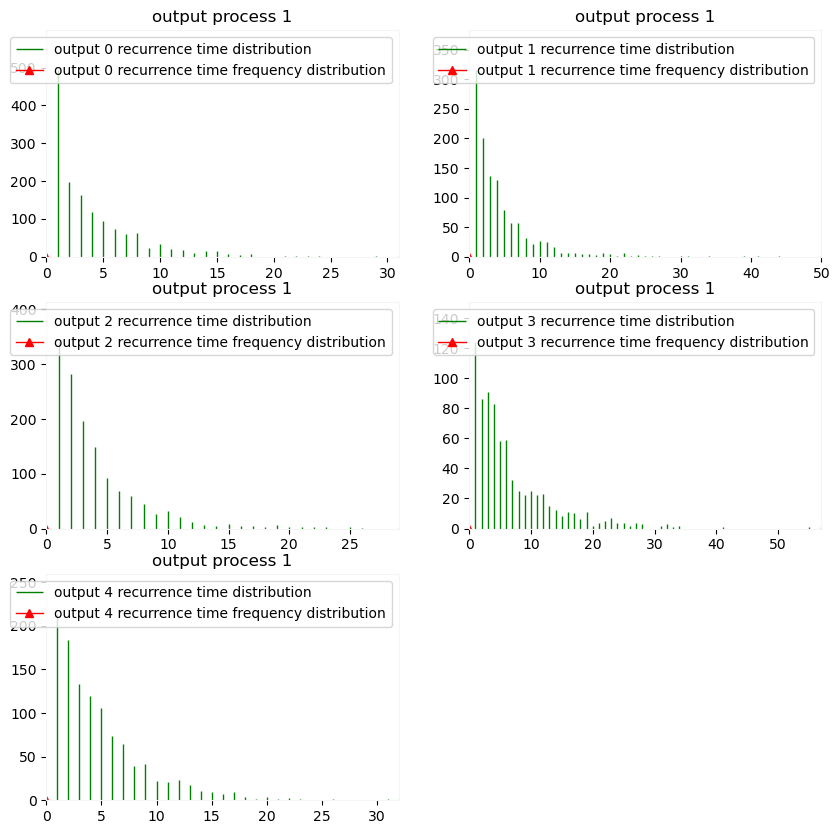

In [33]:
hsmc_est.plot("Recurrence", 1)


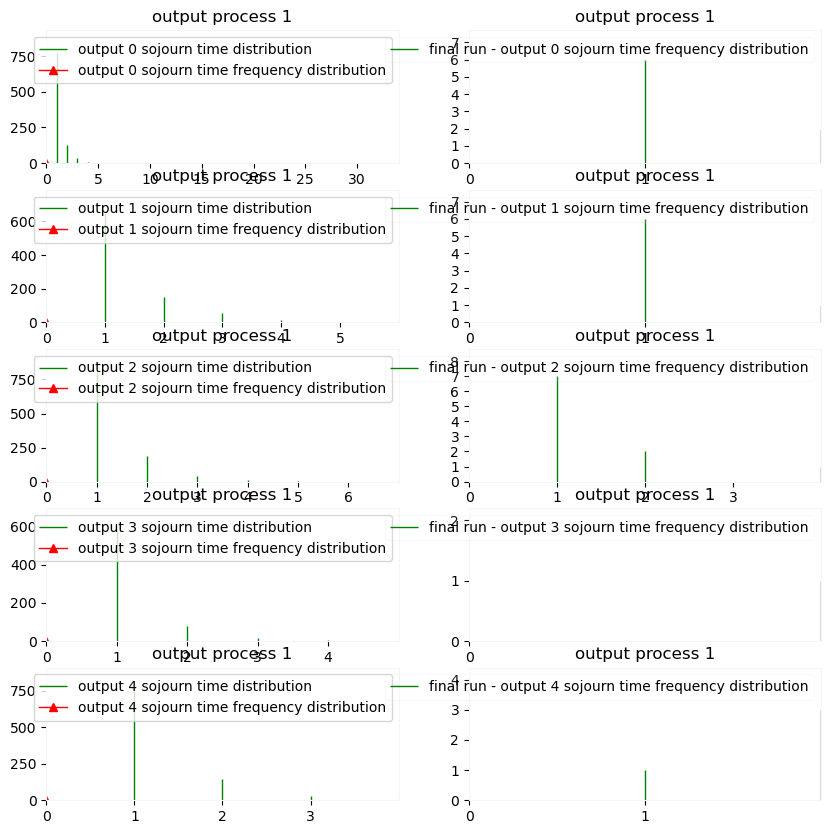

In [34]:
hsmc_est.plot("Sojourn", 1)


Note that you may also plot figures individually (and not as a collection of figures)

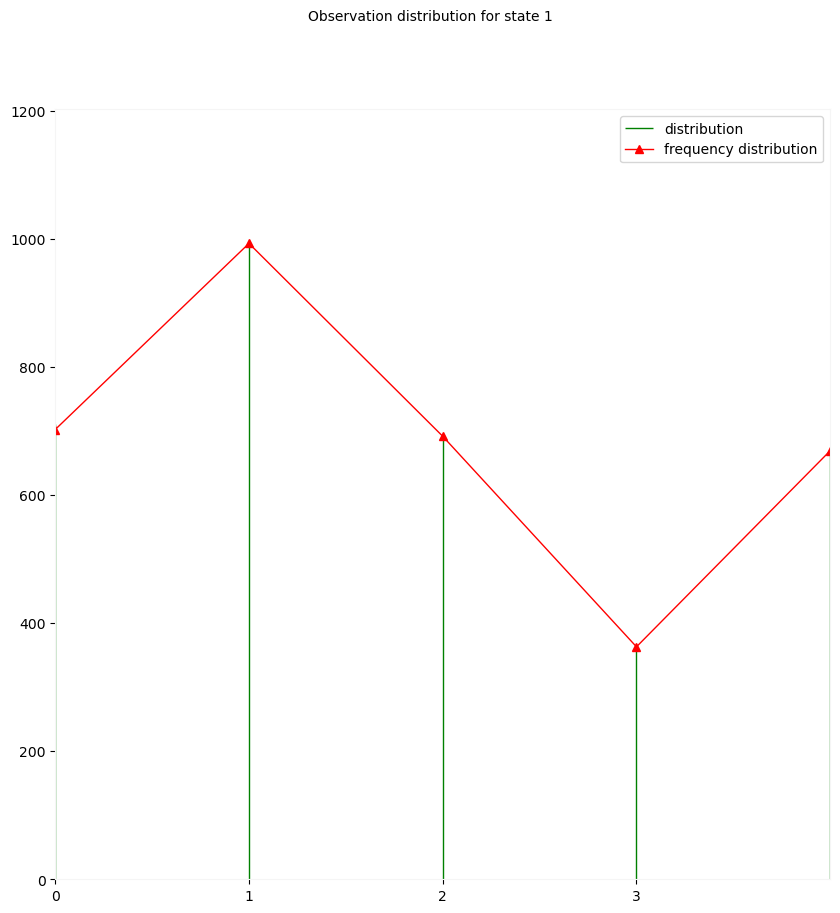

In [35]:
from openalea.sequence_analysis import seq_map
hsmc_est.extract(seq_map['Observation'],1,1).plot(Title="Observation distribution for state 1")

In [ ]:
hsmc_est.extract(seq_map['Sojourn'],0,0).plot(Title="Sojourn distribution for state 0")

### Reestimate from true model

In [ ]:
hsmc_est = Estimate(obs, "HIDDEN_SEMI-MARKOV", hsm, Nbiteration=300)   
print(hsmc_est.display())

In [ ]:
hsmc_est.plot("Observation", 1)


## TODO: check why single plot

In [ ]:
hsmc_est.plot("Observation", 2)

In [ ]:
hsmc_est.plot("Sojourn", 0)

# State restoration: Viterbi algorithm

In [ ]:
restored = hsmc_est.state_sequence_computation(obs, True)

Percentages of correct restoration per state value

In [ ]:
# number of values in state 0
v0 = len([i for s in range(len(seq)) for i in range(len(seq[s])) if seq[s][i][0] == 0])
# number of values in state 0 with restored state 1
m0 = len([i for s in range(len(seq)) for i in range(len(seq[s])) if seq[s][i][0] == 0 and restored[s][i][0] == 1])
# number of values in state 1
v1 = len([i for s in range(len(seq)) for i in range(len(seq[s])) if seq[s][i][0] == 1])
# number of values in state 0 with restored state 1
m1 = len([i for s in range(len(seq)) for i in range(len(seq[s])) if seq[s][i][0] == 1 and restored[s][i][0] == 0])
# number of values in state 2
v2 = len([i for s in range(len(seq)) for i in range(len(seq[s])) if seq[s][i][0] == 2])
# number of values in state 2 with restored state 2
m2 = len([i for s in range(len(seq)) for i in range(len(seq[s])) if seq[s][i][0] == 2 and restored[s][i][0] == 2])
print((m0/v0, m1/v1, m2/v2))
